# Overfitting & Underfitting — a step-by-step, runnable notebook

A model can score **perfectly** on the data it trained on and still fail on new data — because it **memorised the noise** instead of learning the signal. This notebook shows that, one measurement at a time, on **real data** (a known curve plus real Gaussian noise, so we can measure what's normally invisible). It is the executable companion to the chapter and to `overfitting_underfitting.py`; every function used here lives in that module, imported so the notebook and the module can never drift apart.

By the end you will have **measured**, not just been told:

1. the **three regimes** as fitted curves — underfit, just-right, overfit — on the same 40 points;
2. the **U-curve**: training error only falls with capacity, validation error falls then rises;
3. the **generalisation gap** (validation − training) as your overfitting diagnostic;
4. the **bias-variance decomposition**, measured over hundreds of resamples, summing to the U;
5. the two **cures** — L2 regularization and more data — working on measured numbers;
6. every fit **cross-checked against scikit-learn**.

Everything runs on CPU in a few seconds, seeded for reproducibility.

## Step 0 — Setup and version banner

We import the real functions from the chapter module (so this notebook uses the *exact same code* the figures and the page use) and print the library versions the results were produced on.

In [1]:
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import sklearn

from overfitting_underfitting import (
    make_dataset, true_function, fit_poly, predict_poly, mse,
    complexity_sweep, sklearn_poly_predict, bias_variance_decomposition,
    ridge_lambda_sweep, learning_curve,
    N_TRAIN, N_VAL, NOISE_SIGMA, TRAIN_SEED, VAL_SEED,
    UNDERFIT_DEGREE, GOOD_DEGREE, OVERFIT_DEGREE, LC_DEGREE,
)

print(f'numpy {np.__version__} | scikit-learn {sklearn.__version__} '
      f'| matplotlib {matplotlib.__version__}')

numpy 2.4.6 | scikit-learn 1.9.0 | matplotlib 3.10.9


## Step 1 — The real data: a known curve seen through noise

We learn a gentle true curve, $f(x) = \cos(1.5\pi x)$ on $x\in[0,1]$, but we only ever observe it through **noisy measurements**: $y = f(x) + \varepsilon$, with $\varepsilon$ Gaussian, standard deviation $\sigma = 0.25$. That noise is the part no model can ever predict — the *irreducible* error. We draw **40** training points. (Using a known curve is what lets us later *measure* bias, variance, and noise separately — impossible on a real dataset where the truth is unknown.)

40 training points | noise sigma = 0.25 | irreducible floor = sigma^2 = 0.0625


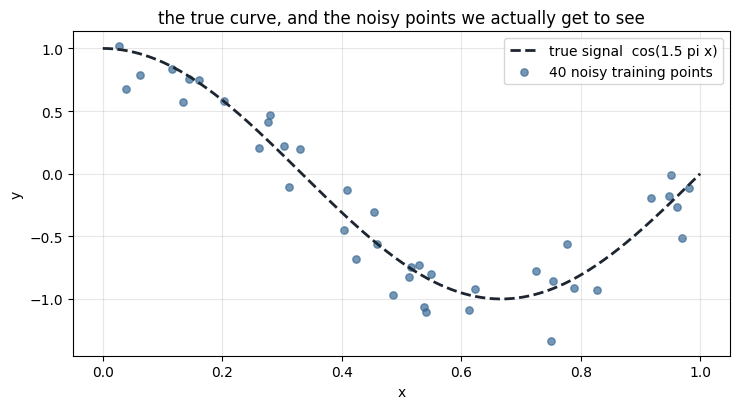

In [2]:
train = make_dataset(N_TRAIN, seed=TRAIN_SEED)
print(f'{train.x.size} training points | noise sigma = {NOISE_SIGMA} | irreducible floor = sigma^2 = {NOISE_SIGMA**2:.4f}')

xs = np.linspace(0, 1, 400)
plt.figure(figsize=(7.5, 4.2))
plt.plot(xs, true_function(xs), '--', color='#1C2530', lw=2, label='true signal  cos(1.5 pi x)')
plt.scatter(train.x, train.y, s=28, color='#3A6B96', alpha=0.7, label='40 noisy training points')
plt.xlabel('x')
plt.ylabel('y')
plt.title('the true curve, and the noisy points we actually get to see')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## Step 2 — Two numbers per model: training error and validation error

**Capacity** = how wiggly a function a model can represent; for a polynomial it is simply the **degree**. We judge a model by **two** errors: on the training points it learned from, and on a large **held-out validation set** (4,000 fresh points) it never saw. Watch the difference: a degree-1 line and a degree-15 polynomial have very different *training* errors — but the number that matters is the *validation* one.

In [3]:
val = make_dataset(N_VAL, seed=VAL_SEED)
for d in (1, 4, 15):
    fit = fit_poly(train.x, train.y, d)
    tr = mse(train.y, predict_poly(fit, train.x))
    va = mse(val.y, predict_poly(fit, val.x))
    print(f'degree {d:2d}: train MSE = {tr:.3f}   validation MSE = {va:.3f}')
print('\nnote: degree 15 has the LOWEST training error but a HIGH validation error — that is overfitting.')

degree  1: train MSE = 0.243   validation MSE = 0.243
degree  4: train MSE = 0.032   validation MSE = 0.068
degree 15: train MSE = 0.024   validation MSE = 0.180

note: degree 15 has the LOWEST training error but a HIGH validation error — that is overfitting.


## Step 3 — See it: underfit / good fit / overfit

The same 40 points, three capacities. **Degree 1** is too rigid — it misses the bend (underfit, high bias). **Degree 4** tracks the true curve (good). **Degree 15** wiggles through nearly every noisy point and swings wildly at the edges (overfit, high variance). This one picture is the whole subject.

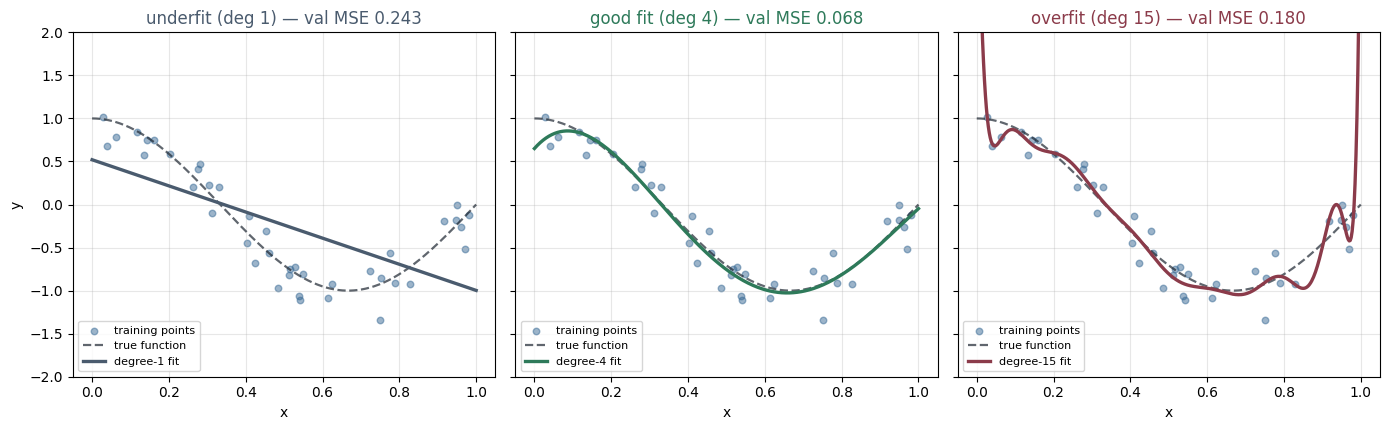

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4.4), sharey=True)
regimes = [(UNDERFIT_DEGREE, 'underfit', '#4A5B6E'),
           (GOOD_DEGREE, 'good fit', '#2E7A5A'),
           (OVERFIT_DEGREE, 'overfit', '#8B3B4A')]
for ax, (deg, name, colour) in zip(axes, regimes):
    fit = fit_poly(train.x, train.y, deg)
    va = mse(val.y, predict_poly(fit, val.x))
    ax.scatter(train.x, train.y, s=22, color='#3A6B96', alpha=0.5, label='training points')
    ax.plot(xs, true_function(xs), '--', color='#1C2530', lw=1.6, alpha=0.7, label='true function')
    ax.plot(xs, predict_poly(fit, xs), color=colour, lw=2.4, label=f'degree-{deg} fit')
    ax.set_ylim(-2, 2)
    ax.set_xlabel('x')
    ax.set_title(f'{name} (deg {deg}) — val MSE {va:.3f}', color=colour)
    ax.legend(fontsize=8, loc='lower left')
    ax.grid(alpha=0.3)
axes[0].set_ylabel('y')
plt.tight_layout()
plt.show()

## Step 4 — The U-curve: sweep every capacity

Now fit *every* degree from 1 to 15 and plot both errors against capacity. The signatures to watch: **training error only ever falls** (more capacity always hugs the training points harder), while **validation error falls, bottoms out at the sweet spot, then rises** — the classic U. The bottom of the red curve is the best model.

sweet-spot degree (lowest validation error) = 4


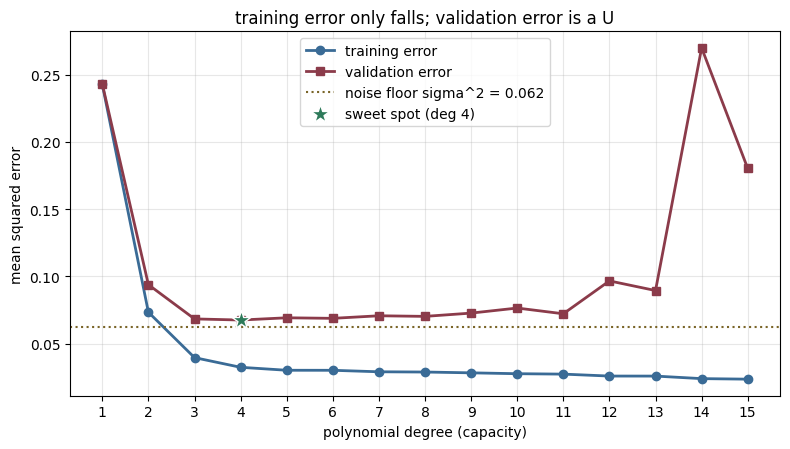

In [5]:
sweep = complexity_sweep(train, val)
print(f'sweet-spot degree (lowest validation error) = {sweep.best_degree}')

plt.figure(figsize=(8, 4.6))
plt.plot(sweep.degrees, sweep.train_mse, 'o-', color='#3A6B96', lw=2, label='training error')
plt.plot(sweep.degrees, sweep.val_mse, 's-', color='#8B3B4A', lw=2, label='validation error')
plt.axhline(NOISE_SIGMA**2, ls=':', color='#7A6528', label=f'noise floor sigma^2 = {NOISE_SIGMA**2:.3f}')
plt.scatter([sweep.best_degree], [sweep.val_mse[sweep.best_degree - 1]], color='#2E7A5A',
            marker='*', s=200, zorder=5, edgecolor='white', label=f'sweet spot (deg {sweep.best_degree})')
plt.xlabel('polynomial degree (capacity)')
plt.ylabel('mean squared error')
plt.title('training error only falls; validation error is a U')
plt.xticks(sweep.degrees)
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## Step 5 — The generalisation gap: your one-number diagnostic

In the wild you can't see bias and variance directly — but you can always compute the **generalisation gap** = validation error − training error. It is how you diagnose a model:

* both errors **high**, small gap → **underfit** (too simple);
* both errors **low**, small gap → **good**;
* training **low**, validation **high**, **large** gap → **overfit** (memorising).

In [6]:
print(f'{"regime":<10}{"degree":>7}{"train":>9}{"val":>9}{"gap":>9}   diagnosis')
for deg, name, diag in [(UNDERFIT_DEGREE, 'underfit', 'both high -> too simple'),
                        (GOOD_DEGREE, 'good', 'both low -> just right'),
                        (OVERFIT_DEGREE, 'overfit', 'big gap -> memorising')]:
    fit = fit_poly(train.x, train.y, deg)
    tr = mse(train.y, predict_poly(fit, train.x))
    va = mse(val.y, predict_poly(fit, val.x))
    print(f'{name:<10}{deg:>7}{tr:>9.3f}{va:>9.3f}{va - tr:>+9.3f}   {diag}')
print('\nthe overfit model has the LOWEST training error yet the LARGEST gap. watch the gap, not train error.')

regime     degree    train      val      gap   diagnosis
underfit        1    0.243    0.243   +0.000   both high -> too simple
good            4    0.032    0.068   +0.035   both low -> just right
overfit        15    0.024    0.180   +0.157   big gap -> memorising

the overfit model has the LOWEST training error yet the LARGEST gap. watch the gap, not train error.


## Step 6 — We measured the real thing: it matches scikit-learn

Are our from-scratch least-squares fits *correct*, or just close? We hand scikit-learn's own solver the identical features and compare predictions. If they match to machine precision, the curves above are the genuine estimator, not a lookalike.

In [7]:
for d in (UNDERFIT_DEGREE, GOOD_DEGREE, OVERFIT_DEGREE):
    ours = predict_poly(fit_poly(train.x, train.y, d), val.x)
    theirs = sklearn_poly_predict(train.x, train.y, val.x, d)
    print(f'degree {d:2d}: max|ours - sklearn| = {np.max(np.abs(ours - theirs)):.2e}  '
          f'match: {bool(np.allclose(ours, theirs, atol=1e-6))}')
print('\n=> our from-scratch least squares reproduces scikit-learn to 1e-6. The measurements are real.')

degree  1: max|ours - sklearn| = 1.11e-16  match: True
degree  4: max|ours - sklearn| = 0.00e+00  match: True
degree 15: max|ours - sklearn| = 3.73e-14  match: True

=> our from-scratch least squares reproduces scikit-learn to 1e-6. The measurements are real.


## Step 7 — Measuring the cause: the bias-variance decomposition

The U-curve is the *symptom*. Its *cause* is the split $\mathbb{E}[(y-\hat f)^2] = \text{bias}^2 + \text{variance} + \sigma^2$. Because we know the true curve and the noise, we can **measure** each term: resample many training sets, fit each, and see how far the *average* fit is from the truth (bias$^2$) and how much fits *bounce* around that average (variance). Watch bias fall and variance rise with degree.

In [8]:
bv = bias_variance_decomposition()
print(f'{"degree":>6}{"bias^2":>10}{"variance":>10}{"noise":>8}{"sum":>10}{"measured":>10}')
for d, b2, var, tot in zip(bv.degrees, bv.bias2, bv.variance, bv.total_measured):
    print(f'{int(d):>6}{b2:>10.4f}{var:>10.4f}{bv.noise:>8.4f}{b2 + var + bv.noise:>10.4f}{tot:>10.4f}')
print(f'\nbias^2 collapses {bv.bias2[0]:.3f} -> {bv.bias2[3]:.4f} (deg 1 -> 4); '
      f'variance explodes {bv.variance[0]:.3f} -> {bv.variance[-1]:.3f} (deg 1 -> {int(bv.degrees[-1])}).')

degree    bias^2  variance   noise       sum  measured
     1    0.1834    0.0138  0.0625    0.2598    0.2605
     2    0.0329    0.0100  0.0625    0.1054    0.1057
     3    0.0032    0.0083  0.0625    0.0740    0.0740
     4    0.0002    0.0119  0.0625    0.0746    0.0745
     5    0.0001    0.0157  0.0625    0.0783    0.0787
     6    0.0000    0.0428  0.0625    0.1053    0.1051
     7    0.0000    0.0714  0.0625    0.1339    0.1343
     8    0.0000    0.1725  0.0625    0.2350    0.2349
     9    0.0003    0.8491  0.0625    0.9119    0.9108

bias^2 collapses 0.183 -> 0.0002 (deg 1 -> 4); variance explodes 0.014 -> 0.849 (deg 1 -> 9).


## Step 8 — The decomposition, plotted: their sum is the U

Plotting the three measured curves on a log scale makes the tradeoff visible: bias$^2$ (blue) falls, variance (red) rises, and their sum plus the noise floor (purple) is the **U** — bottoming at the same sweet spot the validation sweep found. This *is* the U-curve, split into its causes.

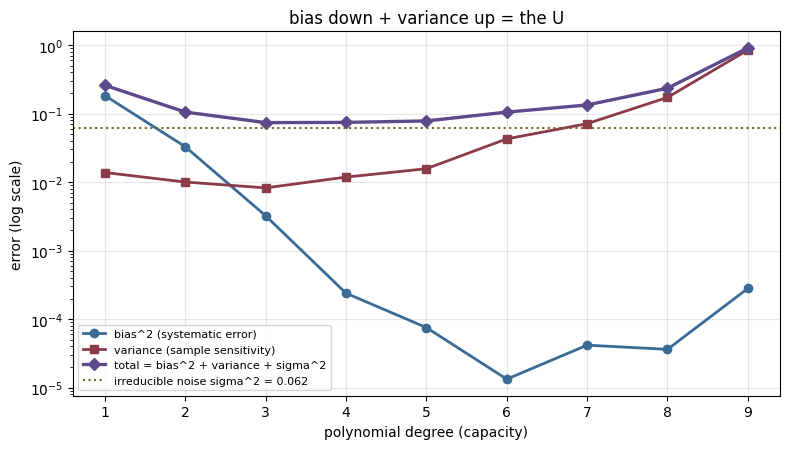

In [9]:
total = bv.bias2 + bv.variance + bv.noise
plt.figure(figsize=(8, 4.6))
plt.plot(bv.degrees, bv.bias2, 'o-', color='#3A6B96', lw=2, label='bias^2 (systematic error)')
plt.plot(bv.degrees, bv.variance, 's-', color='#8B3B4A', lw=2, label='variance (sample sensitivity)')
plt.plot(bv.degrees, total, 'D-', color='#5D4A8A', lw=2.4, label='total = bias^2 + variance + sigma^2')
plt.axhline(bv.noise, ls=':', color='#7A6528', label=f'irreducible noise sigma^2 = {bv.noise:.3f}')
plt.yscale('log')
plt.xlabel('polynomial degree (capacity)')
plt.ylabel('error (log scale)')
plt.title('bias down + variance up = the U')
plt.xticks(bv.degrees)
plt.legend(fontsize=8, loc='lower left')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## Step 9 — The decomposition is an equation, and we check it

The theorem is not a metaphor: bias$^2 +$ variance $+ \sigma^2$ should **equal** the independently-measured test error at every degree. We measured the total a second way (scoring the fits against fresh noisy targets) — here is the equation holding, degree by degree.

In [10]:
worst = 0.0
for d, b2, var, tot in zip(bv.degrees, bv.bias2, bv.variance, bv.total_measured):
    s = b2 + var + bv.noise
    rel = abs(s - tot) / tot
    worst = max(worst, rel)
    print(f'degree {int(d):>2}: bias^2+var+noise = {s:8.4f}   measured = {tot:8.4f}   rel. error {rel:.1%}')
print(f'\nlargest relative mismatch across all degrees: {worst:.1%}  (pure Monte-Carlo noise). The identity holds.')

degree  1: bias^2+var+noise =   0.2598   measured =   0.2605   rel. error 0.3%
degree  2: bias^2+var+noise =   0.1054   measured =   0.1057   rel. error 0.3%
degree  3: bias^2+var+noise =   0.0740   measured =   0.0740   rel. error 0.0%
degree  4: bias^2+var+noise =   0.0746   measured =   0.0745   rel. error 0.2%
degree  5: bias^2+var+noise =   0.0783   measured =   0.0787   rel. error 0.5%
degree  6: bias^2+var+noise =   0.1053   measured =   0.1051   rel. error 0.2%
degree  7: bias^2+var+noise =   0.1339   measured =   0.1343   rel. error 0.3%
degree  8: bias^2+var+noise =   0.2350   measured =   0.2349   rel. error 0.1%
degree  9: bias^2+var+noise =   0.9119   measured =   0.9108   rel. error 0.1%

largest relative mismatch across all degrees: 0.5%  (pure Monte-Carlo noise). The identity holds.


## Step 10 — Cure 1: regularization (an L2 penalty) tames the overfit model

You can leave a model's capacity in place but **discourage it from using it recklessly**. **L2 regularization** adds $\lambda\lVert w\rVert^2$ to the loss, penalising large weights. Since the wild overfit wiggles *need* large weights, shrinking the weights kills the wiggles — variance drops for a small bias cost. We take the wildly-overfit **degree-15** model and sweep $\lambda$: watch validation error fall back toward the sweet spot, then rise again if we over-penalise (a U in $\lambda$ too).

overfit degree-15 model, lambda=0 : validation MSE = 0.180
best-penalised model, lambda=0.489: validation MSE = 0.075
sweet-spot degree-4 model         : validation MSE = 0.068  (for comparison)
-> ridge cut the overfit error by 58%, without dropping any capacity.


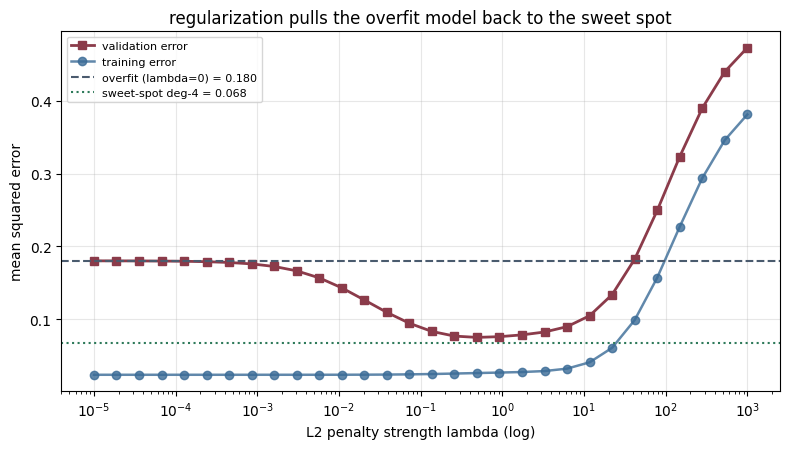

In [11]:
rs = ridge_lambda_sweep(train, val)
best_val = float(rs.val_mse.min())
sweet_val = sweep.val_mse[sweep.best_degree - 1]
print(f'overfit degree-15 model, lambda=0 : validation MSE = {rs.unpenalised_val_mse:.3f}')
print(f'best-penalised model, lambda={rs.best_lambda:.3g}: validation MSE = {best_val:.3f}')
print(f'sweet-spot degree-{sweep.best_degree} model         : validation MSE = {sweet_val:.3f}  (for comparison)')
print(f'-> ridge cut the overfit error by {100 * (rs.unpenalised_val_mse - best_val) / rs.unpenalised_val_mse:.0f}%, without dropping any capacity.')

plt.figure(figsize=(8, 4.6))
plt.plot(rs.lambdas, rs.val_mse, 's-', color='#8B3B4A', lw=2, label='validation error')
plt.plot(rs.lambdas, rs.train_mse, 'o-', color='#3A6B96', lw=1.8, alpha=0.8, label='training error')
plt.axhline(rs.unpenalised_val_mse, ls='--', color='#4A5B6E', label=f'overfit (lambda=0) = {rs.unpenalised_val_mse:.3f}')
plt.axhline(sweet_val, ls=':', color='#2E7A5A', label=f'sweet-spot deg-{sweep.best_degree} = {sweet_val:.3f}')
plt.xscale('log')
plt.xlabel('L2 penalty strength lambda (log)')
plt.ylabel('mean squared error')
plt.title('regularization pulls the overfit model back to the sweet spot')
plt.legend(fontsize=8)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## Step 11 — And our ridge matches scikit-learn too

Same correctness check as Step 6, for the regularized fit: our from-scratch ridge should reproduce scikit-learn's `Ridge` at the best $\lambda$.

In [12]:
ours = predict_poly(fit_poly(train.x, train.y, OVERFIT_DEGREE, l2=rs.best_lambda), val.x)
theirs = sklearn_poly_predict(train.x, train.y, val.x, OVERFIT_DEGREE, l2=rs.best_lambda)
print(f'ridge (lambda={rs.best_lambda:.3g}) max|ours - sklearn| = {np.max(np.abs(ours - theirs)):.2e}')
print(f'match: {bool(np.allclose(ours, theirs, atol=1e-6))}')

ridge (lambda=0.489) max|ours - sklearn| = 1.27e-14
match: True


## Step 12 — Cure 2: more data (noise can't be memorised in bulk)

The other cure needs no cleverness. An overfit model works by memorising the *specific* noise in its points — but you can only memorise so much. Fix a mildly-overfitting **degree-6** model and grow the training set from 20 to 600 points. The **generalisation gap collapses**: with more data the model is forced to fit the signal (the thing all points agree on) instead of the noise.

 n_train    train      val      gap
      20    0.040    0.609    0.569
      30    0.049    0.243    0.193
      50    0.052    0.079    0.026
      80    0.057    0.070    0.013
     150    0.060    0.066    0.006
     300    0.062    0.064    0.003
     600    0.062    0.064    0.001
-> the gap shrank from 0.569 (n=20) to 0.001 (n=600).


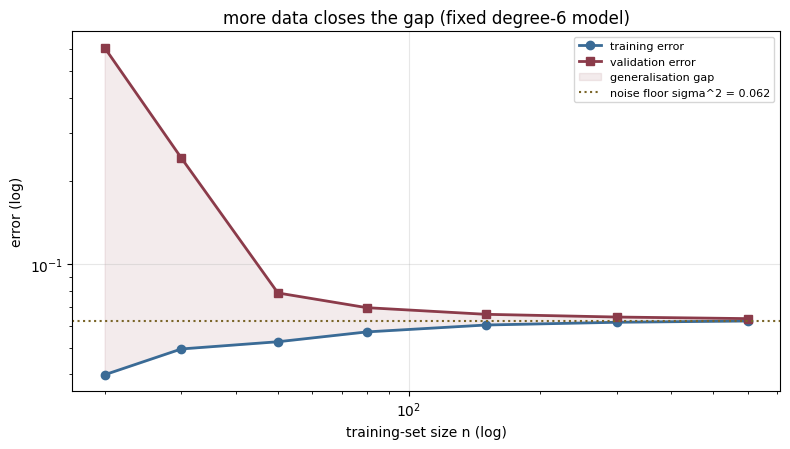

In [13]:
lc = learning_curve(val)
print(f'{"n_train":>8}{"train":>9}{"val":>9}{"gap":>9}')
for n, tr, va, g in zip(lc.sizes, lc.train_mse, lc.val_mse, lc.gap):
    print(f'{int(n):>8}{tr:>9.3f}{va:>9.3f}{g:>9.3f}')
print(f'-> the gap shrank from {lc.gap[0]:.3f} (n={int(lc.sizes[0])}) to {lc.gap[-1]:.3f} (n={int(lc.sizes[-1])}).')

plt.figure(figsize=(8, 4.6))
plt.plot(lc.sizes, lc.train_mse, 'o-', color='#3A6B96', lw=2, label='training error')
plt.plot(lc.sizes, lc.val_mse, 's-', color='#8B3B4A', lw=2, label='validation error')
plt.fill_between(lc.sizes, lc.train_mse, lc.val_mse, color='#8B3B4A', alpha=0.1, label='generalisation gap')
plt.axhline(NOISE_SIGMA**2, ls=':', color='#7A6528', label=f'noise floor sigma^2 = {NOISE_SIGMA**2:.3f}')
plt.xscale('log')
plt.yscale('log')
plt.xlabel('training-set size n (log)')
plt.ylabel('error (log)')
plt.title(f'more data closes the gap (fixed degree-{LC_DEGREE} model)')
plt.legend(fontsize=8)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## Recap

In one runnable notebook, on real measured data, we saw the whole of over- and under-fitting:

| Step | What we did | The takeaway |
|---|---|---|
| 1–2 | a known curve seen through noise; train vs val error | judge on **held-out** data, not training error |
| 3 | the three fits | underfit (high bias) / good / overfit (high variance) — *seen* |
| 4 | the complexity sweep | training error only falls; validation error is a **U** |
| 5 | the generalisation gap | val − train diagnoses under/over-fitting in one number |
| 6, 11 | match scikit-learn | the fits are the **genuine** estimator, to 1e-6 |
| 7–9 | the bias-variance decomposition | bias↓ + variance↑ + noise = the U, as an **equation** |
| 10 | ridge (L2) regularization | penalise weights → less variance → overfit **cured**, capacity kept |
| 12 | more data | the gap collapses as n grows — noise can't be memorised in bulk |

A model's error is **bias² + variance + irreducible noise**. Underfitting is high bias; overfitting is high variance; the sweet spot minimises their sum. You find it — and the right regularization — by **measuring on data the model never saw**. That is the diagnostic under every model in the rest of the repo.